In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [4]:
# load the dataset

df = pd.read_csv("../data/raw/personality_dataset.csv")

In [5]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [6]:
df.sample(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
2447,2.0,No,9.0,6.0,No,10.0,6.0,Introvert
2332,0.0,No,5.0,3.0,No,14.0,7.0,Extrovert
672,0.0,No,7.0,4.0,No,6.0,6.0,Extrovert
678,6.0,Yes,2.0,1.0,Yes,1.0,1.0,Introvert
940,2.0,No,9.0,6.0,No,11.0,5.0,Extrovert
1374,5.0,Yes,3.0,2.0,Yes,2.0,2.0,Introvert
736,9.0,Yes,2.0,2.0,Yes,3.0,0.0,Introvert
2217,5.0,Yes,1.0,2.0,Yes,3.0,NaN,Introvert
2496,NaN,Yes,3.0,2.0,Yes,2.0,1.0,Introvert


In [7]:
# Dataset inspection

df.shape

(2900, 8)

In [8]:
# columns names

df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='str')

In [9]:
# data types

df.dtypes

Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [11]:
# Find the Missing Values

df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [12]:
# missing values presentages

missing_pct = (
    df.isnull().sum() /
    len(df)
) * 100

missing_pct.sort_values(
    ascending=False
)

Friends_circle_size          2.655172
Stage_fear                   2.517241
Going_outside                2.275862
Post_frequency               2.241379
Time_spent_Alone             2.172414
Social_event_attendance      2.137931
Drained_after_socializing    1.793103
Personality                  0.000000
dtype: float64

In [13]:
# checking duplicates values

df.duplicated().sum()

np.int64(388)

In [14]:
# uniques values

for col in df.columns:
    print(col)
    print(df[col].nunique())
    print()

Time_spent_Alone
12

Stage_fear
2

Social_event_attendance
11

Going_outside
8

Drained_after_socializing
2

Friends_circle_size
16

Post_frequency
11

Personality
2



In [15]:
# Target distribution

df["Personality"].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

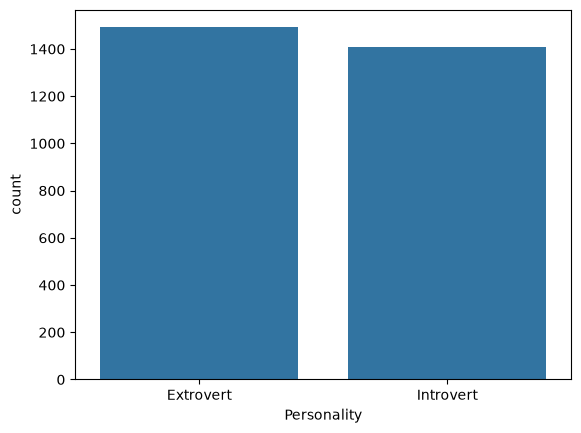

In [21]:
# visualize

sns.countplot(
    data=df,
    x="Personality"
)
plt.show()

In [22]:
## Statistical Summary
## Numerical columns

df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


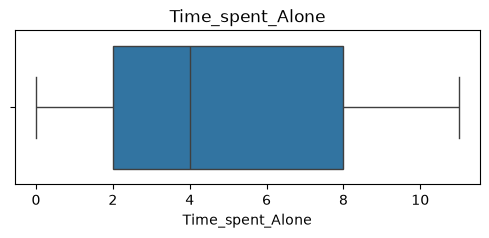

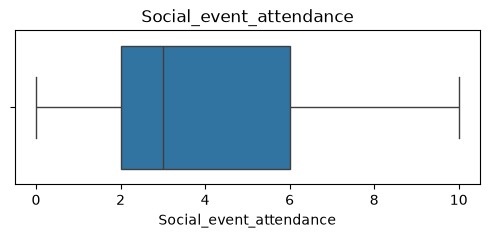

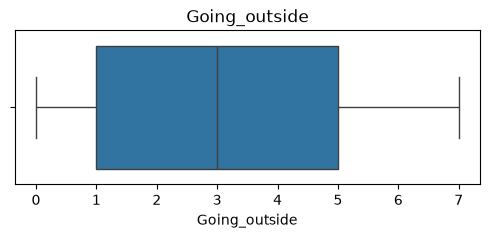

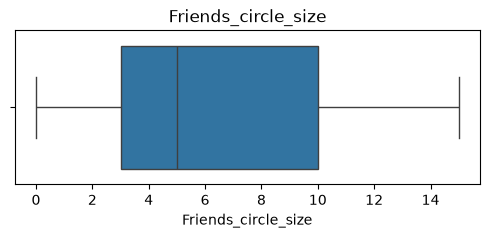

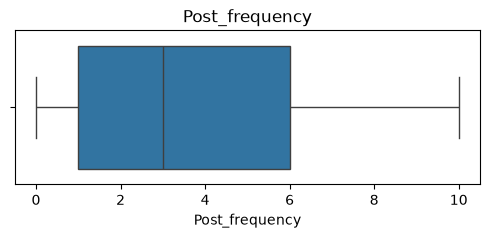

In [23]:
# Outlier Detection
# Boxplots

numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(
        x=df[col]
    )
    plt.title(col)
    plt.show()

In [24]:
# IQR method

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

In [25]:
# Count outliers

outliers = (
    (
        df[numeric_cols] <
        (Q1 - 1.5*IQR)
    ) |
    (
        df[numeric_cols] >
        (Q3 + 1.5*IQR)
    )
)

outliers.sum()

Time_spent_Alone           0
Social_event_attendance    0
Going_outside              0
Friends_circle_size        0
Post_frequency             0
dtype: int64

In [26]:
# Exploratory Data Analysis

<Axes: xlabel='Personality', ylabel='count'>

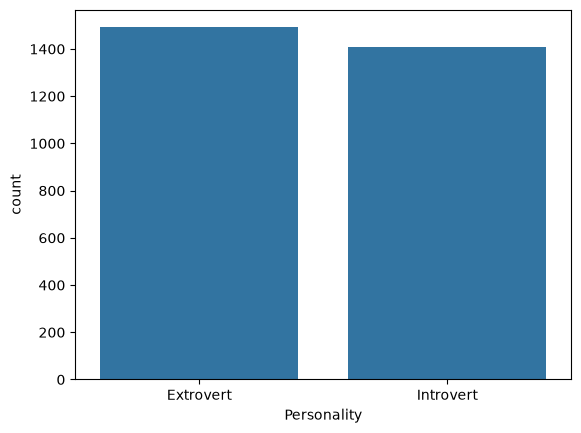

In [27]:
# Personality Distribution

sns.countplot(
    x="Personality",
    data=df
)

<Axes: xlabel='Personality', ylabel='Time_spent_Alone'>

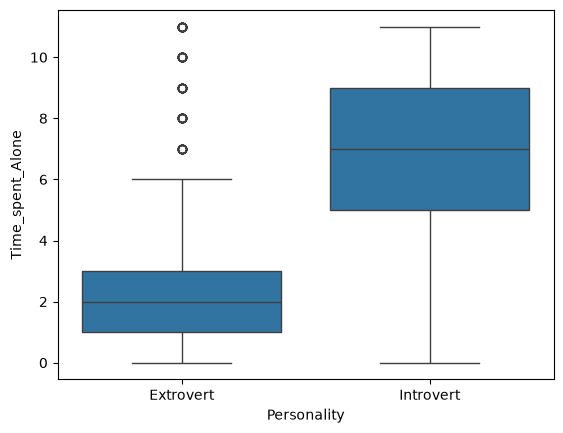

In [28]:
# Time Alone vs Personality

sns.boxplot(
    x="Personality",
    y="Time_spent_Alone",
    data=df
)

<Axes: xlabel='Personality', ylabel='Social_event_attendance'>

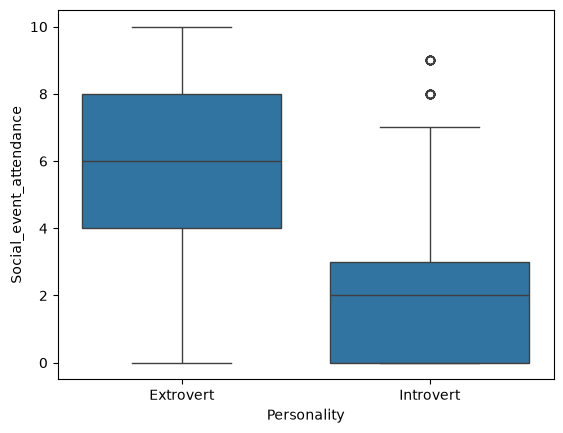

In [29]:
# Social Events vs Personality

sns.boxplot(
    x="Personality",
    y="Social_event_attendance",
    data=df
)

<Axes: xlabel='Personality', ylabel='Friends_circle_size'>

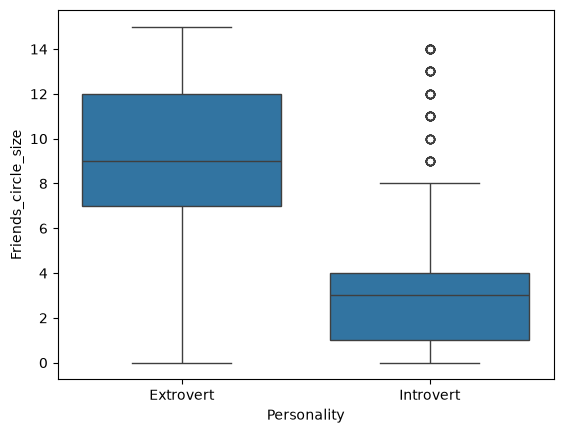

In [30]:
# Friend Circle Size

sns.boxplot(
    x="Personality",
    y="Friends_circle_size",
    data=df
)

<Axes: xlabel='Stage_fear', ylabel='count'>

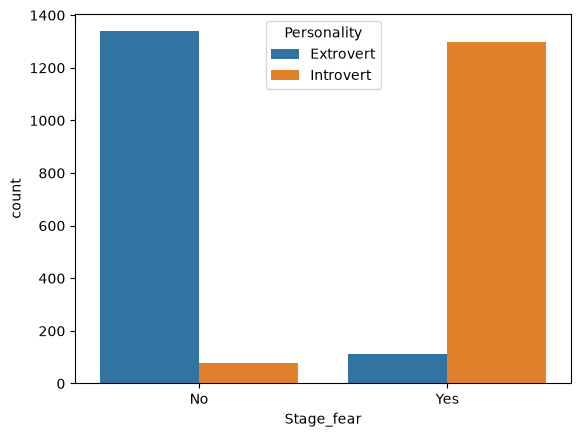

In [31]:
# Stage Fear Analysis

pd.crosstab(
    df["Stage_fear"],
    df["Personality"]
)

sns.countplot(
    x="Stage_fear",
    hue="Personality",
    data=df
)

In [36]:
# Correlation Analysis 
# Encode temporary copy

eda_df = df.copy()

In [38]:
# Convert categories

for col in eda_df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    eda_df[col] = le.fit_transform(eda_df[col])
    print(f"Encoded column: {col} | Unique values: {eda_df[col].nunique()}")

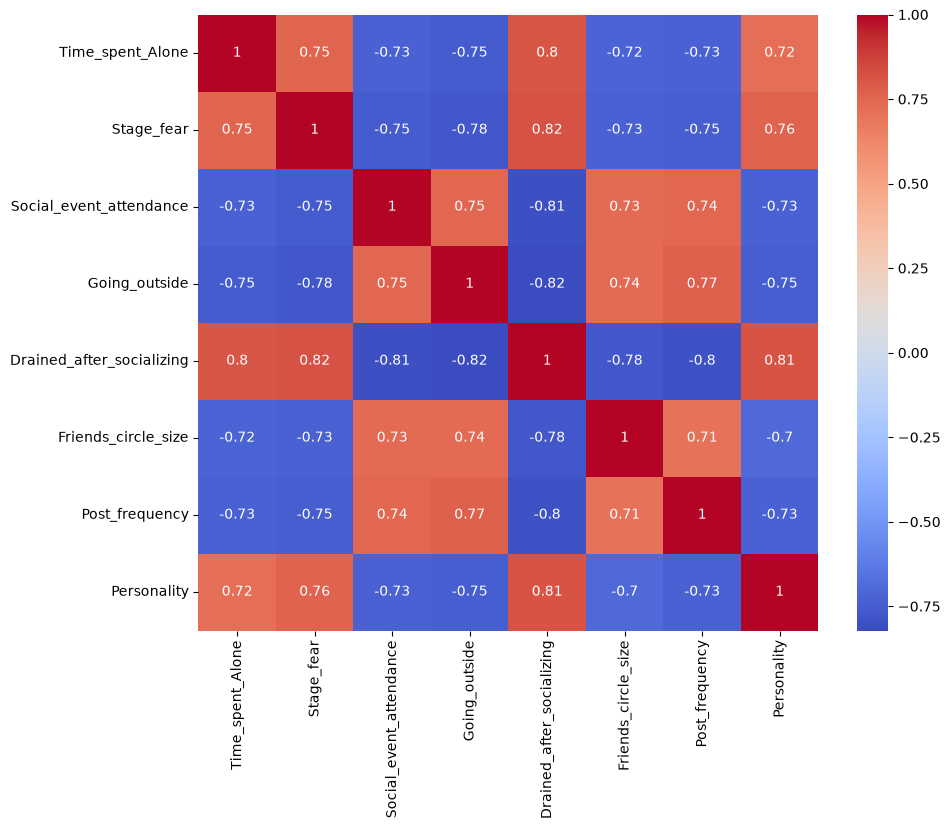

In [39]:
# Correlation matrix

corr = eda_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [40]:
# Feature Engineering
# Social Activity Score

df["Social_Activity_Score"] = (
    df["Social_event_attendance"] +
    df["Going_outside"] +
    df["Post_frequency"]
)

In [41]:
# Isolation Index

df["Isolation_Index"] = (
    df["Time_spent_Alone"] -
    df["Social_event_attendance"]
)

In [42]:
# Create a Cleaning Copy - Don't modify the original dataset directly

clean_df = df.copy()

In [43]:
# Handle Duplicate Records

duplicates = clean_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 388


In [44]:
# Remove duplicates values

clean_df = clean_df.drop_duplicates()

In [45]:
clean_df.duplicated().sum()

np.int64(0)

In [46]:
# Handles missing values

clean_df.isnull().sum()

Time_spent_Alone              61
Stage_fear                    73
Social_event_attendance       61
Going_outside                 65
Drained_after_socializing     51
Friends_circle_size           75
Post_frequency                63
Personality                    0
Social_Activity_Score        183
Isolation_Index              121
dtype: int64

In [50]:
# Numerical Features - Fill missing values with the median

from sklearn.impute import SimpleImputer
numeric_columns = clean_df.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy="median")

clean_df[numeric_columns] = num_imputer.fit_transform(
    clean_df[numeric_columns]
)

In [53]:
# Categorical Features - Fill missing values with the most frequent value

categorical_columns = clean_df.select_dtypes(
    include=['object', 'string', 'category']
).columns

cat_imputer = SimpleImputer(strategy="most_frequent")

clean_df[categorical_columns] = cat_imputer.fit_transform(
    clean_df[categorical_columns]
)

In [54]:
clean_df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64

In [56]:
# Verify Data Types

clean_df.info()

<class 'pandas.DataFrame'>
Index: 2512 entries, 0 to 2899
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2512 non-null   float64
 1   Stage_fear                 2512 non-null   str    
 2   Social_event_attendance    2512 non-null   float64
 3   Going_outside              2512 non-null   float64
 4   Drained_after_socializing  2512 non-null   str    
 5   Friends_circle_size        2512 non-null   float64
 6   Post_frequency             2512 non-null   float64
 7   Personality                2512 non-null   str    
 8   Social_Activity_Score      2512 non-null   float64
 9   Isolation_Index            2512 non-null   float64
dtypes: float64(7), str(3)
memory usage: 215.9 KB


In [57]:
# Final Dataset Validation - verify that the cleaned dataset is ready for preprocessing

print("Shape:", clean_df.shape)

print("Missing values:")
print(clean_df.isnull().sum())

print("Duplicate rows:", clean_df.duplicated().sum())

Shape: (2512, 10)
Missing values:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64
Duplicate rows: 13


In [58]:
print("Duplicate rows before:", clean_df.duplicated().sum())

Duplicate rows before: 13


In [59]:
clean_df = clean_df.drop_duplicates()

In [60]:
print("Duplicate rows after:", clean_df.duplicated().sum())

Duplicate rows after: 0


In [61]:
print("Shape:", clean_df.shape)

print("Missing values:")
print(clean_df.isnull().sum())

print("Duplicate rows:", clean_df.duplicated().sum())

Shape: (2499, 10)
Missing values:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64
Duplicate rows: 0
